# P3 · Drug–Gene Interaction Collection
**Input :** `results/tables/hub_genes.csv` · `results/tables/survival_filtered_genes.csv`  
**Outputs:** `results/tables/dgi_edges_gnn.csv` · `results/figures/dgi_summary_dashboard.png`

Queries DGIdb (GraphQL), ChEMBL (REST), and OpenTargets (GraphQL) for all known
drugs targeting the hub genes. Automatically falls back to a curated literature
dataset of 37 interactions if APIs are unreachable.

Each drug-gene pair receives a composite score weighted by interaction confidence,
publication count, clinical phase, FDA approval, and hub score.
The output `dgi_edges_gnn.csv` is the direct input to notebook P4 (GNN).

**Run order:** P1 → P2 → **P3** → P4


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from paths import REPO_ROOT, PROC_DIR, FIGURES_DIR, TABLES_DIR, REPORTS_DIR, MODELS_DIR
print(f"Repo root : {REPO_ROOT}")
print(f"Tables    : {TABLES_DIR}")
print(f"Figures   : {FIGURES_DIR}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD
Tables    : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\tables
Figures   : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures


In [2]:
import sys
sys.path.insert(0, str(REPO_ROOT / "scripts"))
from utils import (query_dgidb, query_chembl, query_opentargets,
                   get_curated_fallback)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("Imports OK")

Imports OK


In [8]:
# ── Database selection — set to True/False to enable/disable each source ──────
USE_DGIDB       = True    # DGIdb GraphQL API
USE_CHEMBL      = False    # ChEMBL REST API
USE_OPENTARGETS = False    # OpenTargets GraphQL API
USE_CURATED     = True    # Built-in curated fallback (always fills gaps)

# Composite score weights — must sum to 1.0
W = {"interaction": 0.35, "publications": 0.20,
     "phase": 0.20, "approved": 0.15, "hub": 0.10}

DRUG_FEAT_COLS = ["approved","immunotherapy","anti_neoplastic","clinical_phase",
                  "interaction_score","n_publications","source_DGIdb","source_ChEMBL",
                  "source_OpenTargets","type_inhibitor","type_agonist","type_antagonist",
                  "type_antibody","type_binder","type_activator"]
GENE_FEAT_COLS = ["hub_score","survival_target"]

print("Database selection:")
print(f"  DGIdb       : {'✓ enabled' if USE_DGIDB       else '✗ disabled'}")
print(f"  ChEMBL      : {'✓ enabled' if USE_CHEMBL      else '✗ disabled'}")
print(f"  OpenTargets : {'✓ enabled' if USE_OPENTARGETS else '✗ disabled'}")
print(f"  Curated     : {'✓ enabled' if USE_CURATED     else '✗ disabled'}")


Database selection:
  DGIdb       : ✓ enabled
  ChEMBL      : ✗ disabled
  OpenTargets : ✗ disabled
  Curated     : ✓ enabled


## Load gene lists

In [4]:
hub_df = pd.read_csv(TABLES_DIR / "hub_genes.csv")
gene_list = hub_df.gene.dropna().unique().tolist()
hub_score_map = hub_df.set_index("gene")["hub_score"].to_dict()     if "hub_score" in hub_df.columns else {}

surv_file = TABLES_DIR / "survival_filtered_genes.csv"
surv_genes = set(pd.read_csv(surv_file)["gene"].dropna())     if surv_file.exists() else set()

print(f"Hub genes        : {len(gene_list)}")
print(f"Survival targets : {len(surv_genes)}")
print(f"Sample genes     : {gene_list[:8]}")

Hub genes        : 1254
Survival targets : 3
Sample genes     : ['GAPDH', 'CD4', 'IL1B', 'IFNG', 'CD8A', 'ALB', 'TLR4', 'IL10']


## Query selected databases

In [7]:
all_edges, apis_ok = [], []

if USE_DGIDB:
    print("Querying DGIdb...")
    dgidb_edges = query_dgidb(gene_list)
    if dgidb_edges:
        all_edges.extend(dgidb_edges)
        apis_ok.append("DGIdb")
        print(f"  → {len(dgidb_edges)} interactions")
    else:
        print("  → No results (API unreachable or no matches)")

if USE_CHEMBL:
    print("Querying ChEMBL...")
    chembl_edges = query_chembl(gene_list)
    if chembl_edges:
        all_edges.extend(chembl_edges)
        apis_ok.append("ChEMBL")
        print(f"  → {len(chembl_edges)} interactions")
    else:
        print("  → No results (API unreachable or no matches)")

if USE_OPENTARGETS:
    print("Querying OpenTargets...")
    ot_edges = query_opentargets(gene_list)
    if ot_edges:
        all_edges.extend(ot_edges)
        apis_ok.append("OpenTargets")
        print(f"  → {len(ot_edges)} interactions")
    else:
        print("  → No results (API unreachable or no matches)")

if USE_CURATED:
    if not all_edges:
        # No live API returned anything — use full curated dataset
        print("No live API results — using full curated fallback...")
        all_edges = get_curated_fallback(gene_list)
        print(f"  → {len(all_edges)} curated interactions")
    else:
        # Fill gaps for genes not covered by selected APIs
        covered = {e["gene"] for e in all_edges}
        missing = [g for g in gene_list if g not in covered]
        if missing:
            curated = get_curated_fallback(missing)
            all_edges.extend(curated)
            print(f"Curated fallback: {len(curated)} interactions added "
                  f"for {len(missing)} uncovered genes")
elif not all_edges:
    print("\nWarning: no databases selected and curated fallback is disabled.")
    print("Enable at least one source in the configuration cell above.")

print(f"\nSources used    : {apis_ok or ['curated fallback']}")
print(f"Raw interactions: {len(all_edges)}")


Querying DGIdb...
    DGIdb: 8118 interactions returned
  → 8118 interactions
Querying OpenTargets...
    OpenTargets: 0 interactions returned
  → No results (API unreachable or no matches)
Curated fallback: 6 interactions added for 699 uncovered genes

Sources used    : ['DGIdb']
Raw interactions: 8124


## Build edge dataframe & composite score

In [9]:
dgi_df = pd.DataFrame(all_edges)

# Ensure all feature columns exist
for col in DRUG_FEAT_COLS:
    if col not in dgi_df.columns: dgi_df[col] = 0
for col in ["approved","immunotherapy","anti_neoplastic"]:
    dgi_df[col] = dgi_df[col].fillna(False).astype(bool)
dgi_df["interaction_score"] = pd.to_numeric(dgi_df.interaction_score, errors="coerce").fillna(0)
dgi_df["n_publications"]    = pd.to_numeric(dgi_df.n_publications,    errors="coerce").fillna(0).astype(int)
dgi_df["clinical_phase"]    = pd.to_numeric(dgi_df.clinical_phase,    errors="coerce").fillna(0).astype(int)
dgi_df["drug"] = dgi_df.drug.str.strip().str.title()
dgi_df["gene"] = dgi_df.gene.str.strip().str.upper()

# Deduplicate: keep highest interaction score per gene-drug pair
dgi_df = (dgi_df.sort_values("interaction_score", ascending=False)
                .drop_duplicates(["gene","drug"], keep="first")
                .reset_index(drop=True))

# Composite score
def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

dgi_df["composite_score"] = (
    W["interaction"]  * norm(dgi_df.interaction_score) +
    W["publications"] * norm(dgi_df.n_publications.clip(0, 30)) +
    W["phase"]        * (dgi_df.clinical_phase / 4) +
    W["approved"]     * dgi_df.approved.astype(float) +
    W["hub"]          * norm(dgi_df.gene.map(hub_score_map).fillna(0)) +
    dgi_df.gene.isin(surv_genes).astype(float) * 0.10
).clip(0, 1).round(4)

dgi_df = dgi_df.sort_values("composite_score", ascending=False).reset_index(drop=True)

print(f"Edges (deduplicated): {len(dgi_df)}")
print(f"Unique genes        : {dgi_df.gene.nunique()}")
print(f"Unique drugs        : {dgi_df.drug.nunique()}")
print(f"Approved drugs      : {dgi_df.approved.sum()}")
dgi_df[["gene","drug","composite_score","approved","clinical_phase","source"]].head(10)

Edges (deduplicated): 8076
Unique genes        : 558
Unique drugs        : 5008
Approved drugs      : 2810


,gene,drug,composite_score,approved,clinical_phase,source
0,TPP1,Cerliponase Alfa,0.7120,True,4,DGIdb
1,IFNGR2,Interferon Gamma-1B,0.6007,True,4,DGIdb
2,EML4,Alectinib,0.5829,True,4,DGIdb
3,NRAS,Trametinib Dimethyl Sulfoxide,0.5794,True,4,DGIdb
4,EML4,Lorlatinib,0.5740,True,4,DGIdb
5,TYROBP,Sorafenib,0.5730,True,4,OpenTargets
6,EML4,Brigatinib,0.5726,True,4,DGIdb
7,EML4,Crizotinib,0.5706,True,4,DGIdb
8,EML4,Ceritinib,0.5692,True,4,DGIdb
9,TYROBP,Regorafenib,0.5203,True,4,ChEMBL


## Summary dashboard

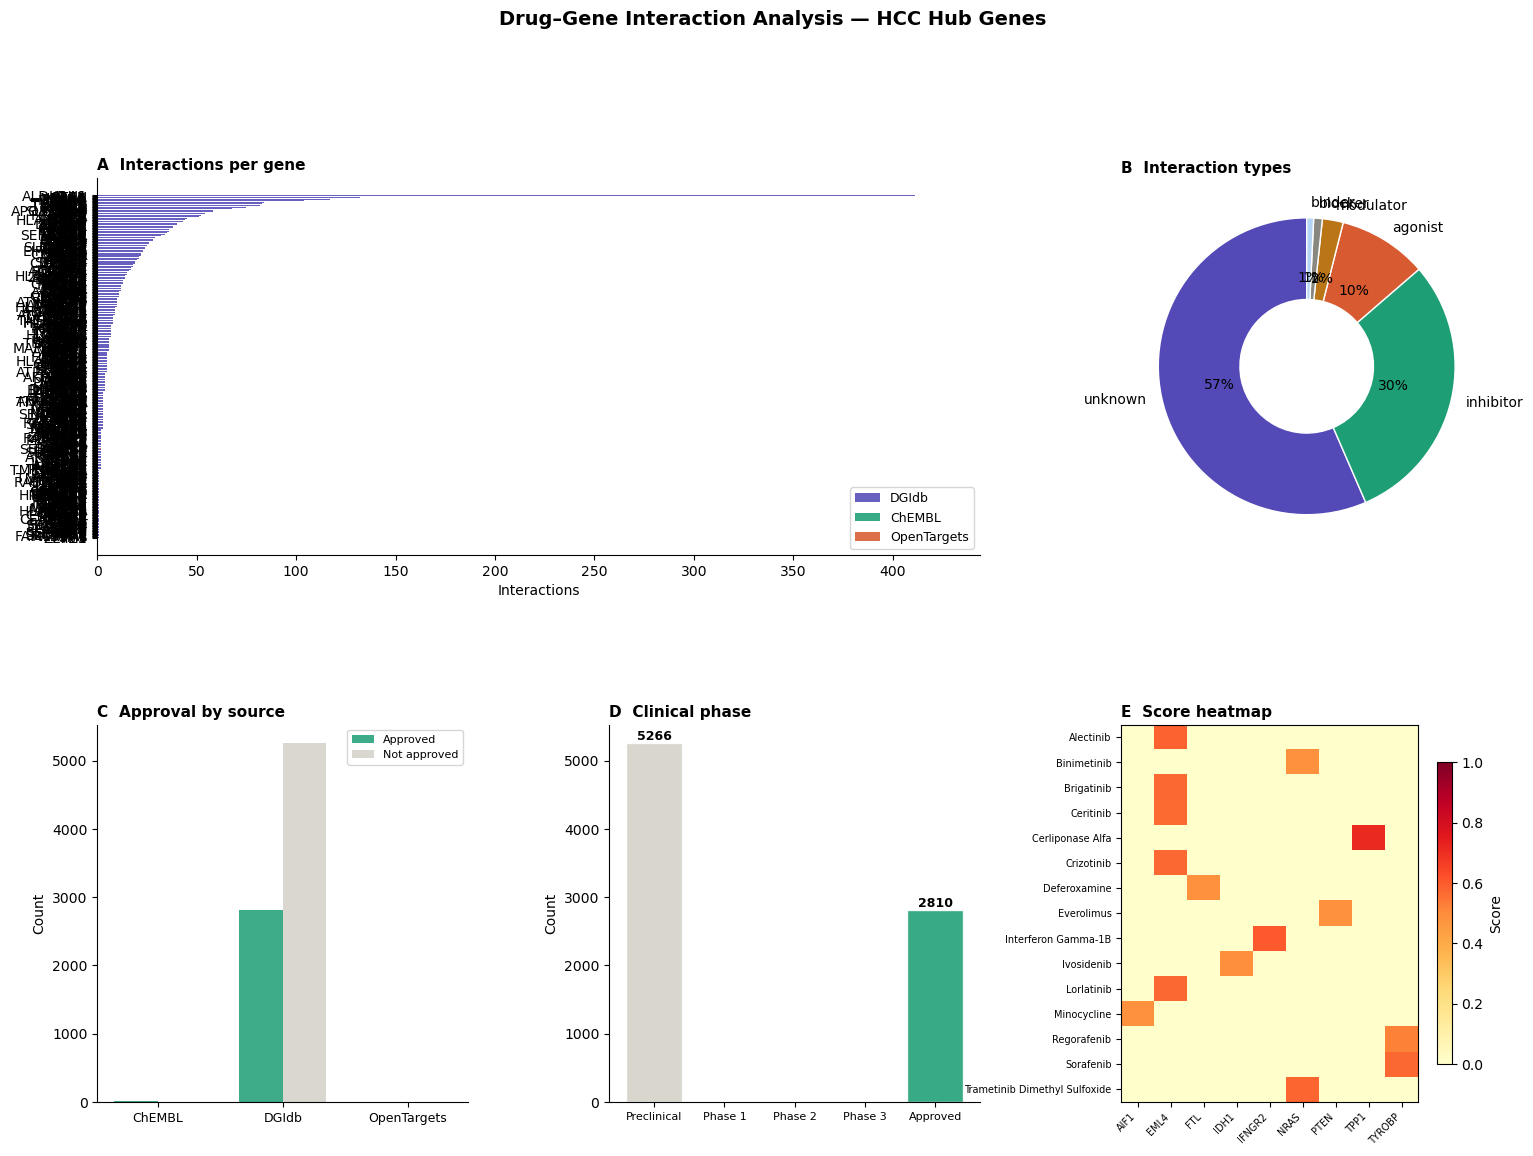

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/dgi_summary_dashboard.png


In [7]:
SRC_COL = {"DGIdb":"#534AB7","ChEMBL":"#1D9E75",
           "OpenTargets":"#D85A30","Curated":"#888780"}

fig = plt.figure(figsize=(18, 12), facecolor="white")
gs  = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# A — interactions per gene
ax1 = fig.add_subplot(gs[0, :2])
gc  = dgi_df.groupby(["gene","source"]).size().unstack(fill_value=0)
gc  = gc.loc[gc.sum(axis=1).sort_values(ascending=True).index]
bot = np.zeros(len(gc))
for src in list(SRC_COL):
    if src in gc.columns:
        v = gc[src].values
        ax1.barh(gc.index, v, left=bot, color=SRC_COL[src],
                 label=src, alpha=0.88, height=0.65)
        bot += v
ax1.set_xlabel("Interactions")
ax1.set_title("A  Interactions per gene", fontsize=11, fontweight="bold", loc="left")
ax1.spines[["top","right"]].set_visible(False); ax1.legend(loc="lower right", fontsize=9)

# B — interaction type donut
ax2 = fig.add_subplot(gs[0, 2])
tc  = dgi_df.interaction_type.str.lower().value_counts().head(6)
cols6 = ["#534AB7","#1D9E75","#D85A30","#BA7517","#888780","#B5D4F4"]
ax2.pie(tc.values, labels=tc.index, colors=cols6[:len(tc)],
        autopct="%1.0f%%", startangle=90,
        wedgeprops={"width":0.55, "edgecolor":"white"})
ax2.set_title("B  Interaction types", fontsize=11, fontweight="bold", loc="left")

# C — approval by source
ax3 = fig.add_subplot(gs[1, 0])
appr = dgi_df.groupby(["source","approved"]).size().unstack(fill_value=0)
x, w = np.arange(len(appr)), 0.35
ax3.bar(x-w/2, appr.get(True,  pd.Series(0, index=appr.index)).values,
        width=w, color="#1D9E75", alpha=0.85, label="Approved")
ax3.bar(x+w/2, appr.get(False, pd.Series(0, index=appr.index)).values,
        width=w, color="#D3D1C7", alpha=0.85, label="Not approved")
ax3.set_xticks(x); ax3.set_xticklabels(appr.index, fontsize=9)
ax3.set_ylabel("Count")
ax3.set_title("C  Approval by source", fontsize=11, fontweight="bold", loc="left")
ax3.spines[["top","right"]].set_visible(False); ax3.legend(fontsize=8)

# D — clinical phase
ax4 = fig.add_subplot(gs[1, 1])
pm  = {0:"Preclinical",1:"Phase 1",2:"Phase 2",3:"Phase 3",4:"Approved"}
po  = ["Preclinical","Phase 1","Phase 2","Phase 3","Approved"]
pv  = [dgi_df.clinical_phase.map(pm).value_counts().get(p, 0) for p in po]
pc  = ["#D3D1C7","#B5D4F4","#378ADD","#185FA5","#1D9E75"]
bars = ax4.bar(po, pv, color=pc, alpha=0.88, edgecolor="white")
for b, v in zip(bars, pv):
    if v: ax4.text(b.get_x()+b.get_width()/2, b.get_height()+.1,
                   str(v), ha="center", va="bottom", fontsize=9, fontweight="bold")
ax4.set_ylabel("Count")
ax4.set_title("D  Clinical phase", fontsize=11, fontweight="bold", loc="left")
ax4.spines[["top","right"]].set_visible(False); ax4.tick_params(axis="x", labelsize=8)

# E — top drug-gene heatmap
ax5  = fig.add_subplot(gs[1, 2])
t15  = dgi_df.head(15)[["drug","gene","composite_score"]]
piv  = t15.pivot_table(index="drug", columns="gene",
                       values="composite_score", fill_value=0)
im   = ax5.imshow(piv.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax5.set_xticks(range(len(piv.columns))); ax5.set_xticklabels(piv.columns, rotation=45, ha="right", fontsize=7)
ax5.set_yticks(range(len(piv.index)));   ax5.set_yticklabels(piv.index, fontsize=7)
plt.colorbar(im, ax=ax5, shrink=0.8, label="Score")
ax5.set_title("E  Score heatmap", fontsize=11, fontweight="bold", loc="left")

fig.suptitle("Drug–Gene Interaction Analysis — HCC Hub Genes",
             fontsize=14, y=1.02, fontweight="bold")
fig.savefig(FIGURES_DIR / "dgi_summary_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR}/dgi_summary_dashboard.png")

## Export GNN-ready edge list

In [8]:
gnn_df = dgi_df.copy()
gnn_df["hub_score"]       = gnn_df.gene.map(hub_score_map).fillna(0)
gnn_df["survival_target"] = gnn_df.gene.isin(surv_genes).astype(int)
for src in ["DGIdb","ChEMBL","OpenTargets"]:
    gnn_df[f"source_{src}"] = (gnn_df.source == src).astype(int)
for it in ["inhibitor","agonist","antagonist","antibody","binder","activator"]:
    gnn_df[f"type_{it}"] = (gnn_df.interaction_type.str.lower() == it).astype(int)

gnn_cols = (
    ["gene","drug","composite_score","approved","immunotherapy","anti_neoplastic",
     "clinical_phase","interaction_score","n_publications"] +
    [f"source_{s}" for s in ["DGIdb","ChEMBL","OpenTargets"]] +
    [f"type_{t}" for t in ["inhibitor","agonist","antagonist","antibody","binder","activator"]] +
    ["hub_score","survival_target","interaction_type","directionality","source"]
)
gnn_df[[c for c in gnn_cols if c in gnn_df.columns]].to_csv(
    TABLES_DIR / "dgi_edges_gnn.csv", index=False)

print(f"Saved: dgi_edges_gnn.csv")
print(f"  Edges  : {len(gnn_df)}")
print(f"  Genes  : {gnn_df.gene.nunique()}")
print(f"  Drugs  : {gnn_df.drug.nunique()}")
print(f"  → Ready for notebook P4 (GNN)")

Saved: dgi_edges_gnn.csv
  Edges  : 8076
  Genes  : 558
  Drugs  : 5008
  → Ready for notebook P4 (GNN)
